In [71]:
import numpy as np
import matplotlib.pyplot as plt  
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
import pandas as pd 

# Questão 01

### Funções auxiliares

In [50]:
class StandardScaler:
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0) + 1e-9  

    def transform(self, X):
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [51]:
kc2 = np.loadtxt("kc2.csv", delimiter=",", skiprows=1)

In [52]:
def train_test_split(X, y, test_size=0.2, seed=42):
    n = X.shape[0]
    indices = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(indices)

    split = int(n * (1 - test_size))
    train_idx = indices[:split]
    test_idx = indices[split:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

In [53]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

In [54]:
def mahalanobis_distance(a, b, VI):
    diff = a - b
    return np.sqrt(np.dot(np.dot(diff.T, VI), diff))

In [55]:
def confusion_matrix_elements(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    return TP, TN, FP, FN

In [56]:
def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN)

In [57]:
def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)
    if (TP + FP) == 0:
        return 0
    return TP / (TP + FP)

In [58]:
def recall(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)
    if (TP + FN) == 0:
        return 0
    return TP / (TP + FN)

In [59]:
def f1_score_manual(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    
    if (p + r) == 0:
        return 0
    return 2 * (p * r) / (p + r)

In [60]:
X = kc2[:, :21]

y = kc2[:, 21]
y = y.astype(int)

### Letra A

In [61]:
class KNN:
    def __init__(self, k=3, distance='euclidean'):
        self.k = k
        self.distance = distance
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
        if self.distance == 'mahalanobis':
            cov_matrix = np.cov(X.T)
            self.VI = np.linalg.inv(cov_matrix)
    
    def _distance(self, a, b):
        if self.distance == 'euclidean':
            return euclidean_distance(a, b)
        elif self.distance == 'mahalanobis':
            return mahalanobis_distance(a, b, self.VI)
    
    def predict(self, X):
        predictions = []
        
        for x in X:
            distances = []
            
            for x_train in self.X_train:
                dist = self._distance(x, x_train)
                distances.append(dist)
            
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            
            most_common = Counter(k_labels).most_common(1)
            predictions.append(most_common[0][0])
        
        return np.array(predictions)

### Letra B

In [ ]:
def evaluate_model(model, X, y, kf):
    accs, precs, recs, f1s = [], [], [], []
    
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        accs.append(accuracy(y_test, y_pred))
        precs.append(precision(y_test, y_pred))
        recs.append(recall(y_test, y_pred))
        f1s.append(f1_score_manual(y_test, y_pred))
    
    return {
        "accuracy_mean": np.mean(accs),
        "accuracy_std": np.std(accs),
        "precision_mean": np.mean(precs),
        "precision_std": np.std(precs),
        "recall_mean": np.mean(recs),
        "recall_std": np.std(recs),
        "f1_mean": np.mean(f1s),
        "f1_std": np.std(f1s),
    }

In [64]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

results = {}

In [65]:
configs = [
    ("KNN_k1_euclidean", KNN(k=1, distance='euclidean')),
    ("KNN_k5_euclidean", KNN(k=5, distance='euclidean')),
    ("KNN_k1_mahalanobis", KNN(k=1, distance='mahalanobis')),
    ("KNN_k5_mahalanobis", KNN(k=5, distance='mahalanobis')),
]

In [66]:
for name, model in configs:
    print(f"Rodando: {name}")
    results[name] = evaluate_model(model, X, y, kf)

Rodando: KNN_k1_euclidean
Rodando: KNN_k5_euclidean
Rodando: KNN_k1_mahalanobis
Rodando: KNN_k5_mahalanobis


In [67]:
tree_configs = [
    ("DecisionTree_gini", DecisionTreeClassifier(criterion='gini')),
    ("DecisionTree_entropy", DecisionTreeClassifier(criterion='entropy')),
]

In [68]:
for name, model in tree_configs:
    print(f"Rodando: {name}")
    results[name] = evaluate_model(model, X, y, kf)

Rodando: DecisionTree_gini
Rodando: DecisionTree_entropy


In [72]:
df_results = pd.DataFrame(results).T
print(df_results)

                      accuracy_mean  accuracy_std  precision_mean  \
KNN_k1_euclidean           0.684199      0.131578        0.708129   
KNN_k5_euclidean           0.779004      0.068272        0.812353   
KNN_k1_mahalanobis         0.712987      0.063713        0.737410   
KNN_k5_mahalanobis         0.746537      0.070168        0.816865   
DecisionTree_gini          0.742208      0.104447        0.756658   
DecisionTree_entropy       0.723377      0.107699        0.740671   

                      precision_std  recall_mean  recall_std   f1_mean  \
KNN_k1_euclidean           0.213928     0.645382    0.198631  0.659995   
KNN_k5_euclidean           0.113820     0.751691    0.122817  0.769817   
KNN_k1_mahalanobis         0.101968     0.645937    0.097195  0.685716   
KNN_k5_mahalanobis         0.151156     0.646947    0.124357  0.709779   
DecisionTree_gini          0.128832     0.733455    0.169007  0.731211   
DecisionTree_entropy       0.109500     0.692396    0.168014  0.704438  

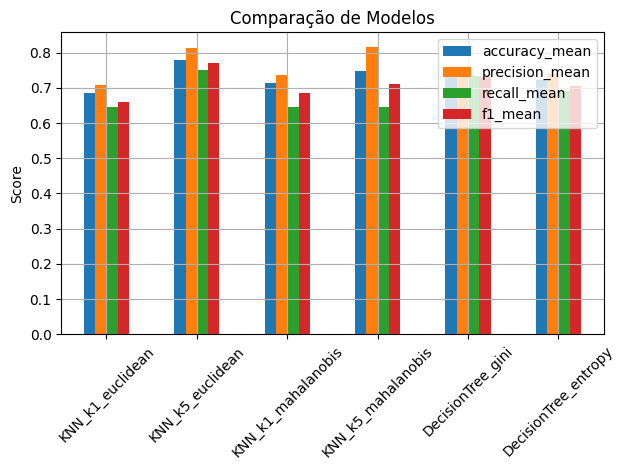

In [73]:
df_plot = df_results[[
    "accuracy_mean",
    "precision_mean",
    "recall_mean",
    "f1_mean"
]]

df_plot.plot(kind="bar")

plt.title("Comparação de Modelos")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()